Loading the dataset: CIFAR-10

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import Sequential

from sklearn.metrics import confusion_matrix
import seaborn as sns



In [2]:
# Load CIFAR-10 dataset
(x_train, y_train), (x_test, y_test) = cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


Visualize the data

<Figure size 393.701x393.701 with 0 Axes>

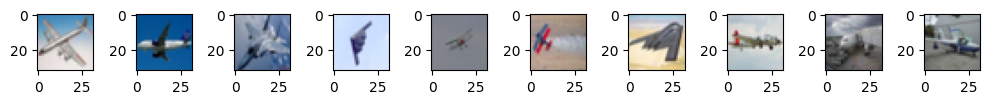

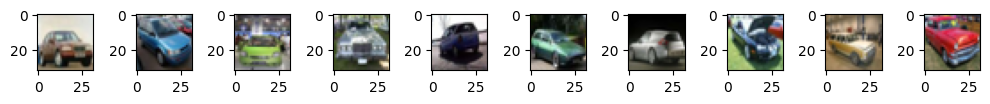

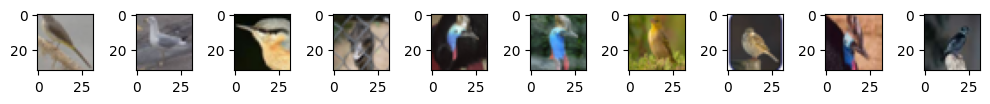

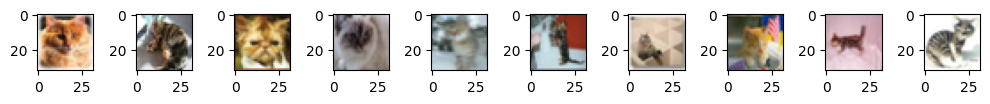

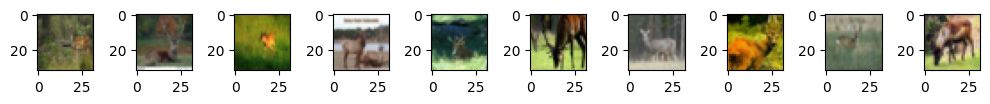

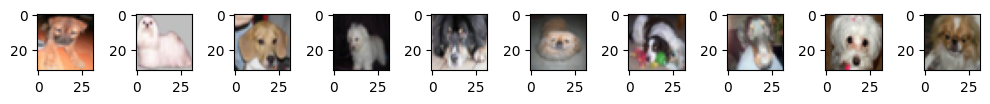

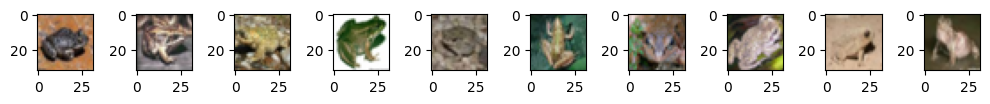

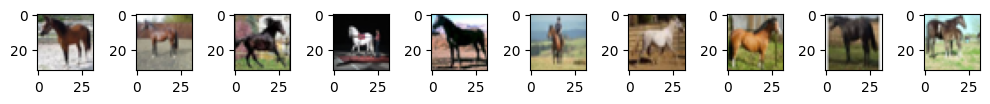

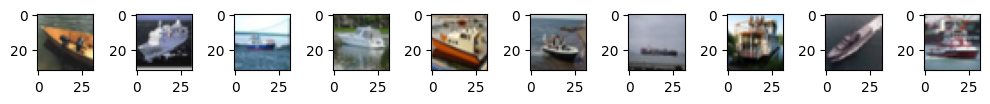

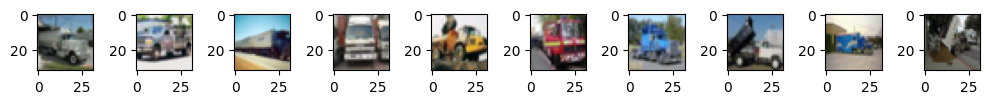

In [3]:

# print(x_train.shape)

num_classes = 10

#add class names

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

fig = plt.figure(figsize=(10*1/2.54, 10*1/2.54))

for idx_class in range(num_classes):

  all_idx = np.where(y_train.flatten() == idx_class)[0]

  # random selection of 10 image of each category
  rand_idx = np.random.choice(all_idx, size=10, replace=False)
  selected = x_train[rand_idx]

  plt.figure(figsize=(10, 10))

  for i in range(10):
    plt.subplot(1, 10, i+1)
    plt.imshow(selected[i])
    plt.tight_layout()

  plt.show()

Data normalization

In [4]:
x_train = x_train.astype("float32") / 255
x_test = x_test.astype("float32") / 255

print(x_train.shape)
print(x_test.shape)

(50000, 32, 32, 3)
(10000, 32, 32, 3)


Prepare the labels

In [5]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

print(y_train.shape)
print(y_test.shape)

(50000, 10)
(10000, 10)


Define the first model

In [6]:
from keras.backend import clear_session
clear_session()

In [12]:
input_shape = (32, 32, 3)

modelRTS01 = Sequential(
    [
        keras.Input(shape=input_shape),


        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D(pool_size=(2,2)),

        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),
        layers.Conv2D(64, kernel_size=(3,3), activation='relu', padding='same'),

        layers.MaxPooling2D(pool_size=(2,2)),



        layers.Flatten(),

        layers.Dense(256, activation='relu'),

        layers.Dropout(0.3),

        layers.Dense(num_classes, activation="softmax")
    ]
)

modelRTS01.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 16, 16, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 4096)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │     1,048,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,163,978 (4.44 MB)

 Trainable params: 1,163,978 (4.44 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
from tensorflow.keras.callbacks import EarlyStopping

modelRTS01.compile(loss='categorical_crossentropy', optimizer='Adam', metrics=['accuracy'])

early_stopping = EarlyStopping(monitor='val_loss', patience=3)

history = modelRTS01.fit(x_train, y_train, batch_size=128, epochs=50, validation_split=0.2, callbacks=[early_stopping]
)

Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 11s 26ms/step - accuracy: 0.3159 - loss: 1.8468 - val_accuracy: 0.5476 - val_loss: 1.2729
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.5706 - loss: 1.2068 - val_accuracy: 0.6357 - val_loss: 1.0190
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.6604 - loss: 0.9625 - val_accuracy: 0.6919 - val_loss: 0.8810
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7137 - loss: 0.8059 - val_accuracy: 0.7217 - val_loss: 0.7921
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7583 - loss: 0.6880 - val_accuracy: 0.7415 - val_loss: 0.7435
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.7901 - loss: 0.5952 - val_accuracy: 0.7483 - val_loss: 0.7200
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8217 - loss: 0.5025 - val_accuracy: 0.7506 - val_loss: 0.7459
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - accuracy: 0.8439 - loss: 0.4380 - val_acc

Test loss: 0.8757977485656738
Test accuracy: 0.7537999749183655
Validation accuracy: 0.8757977485656738
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


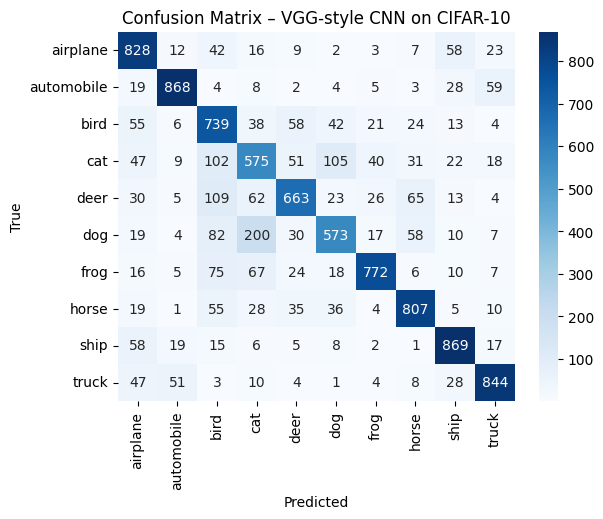

In [ ]:
score = modelRTS01.evaluate(x_test, y_test, verbose=0)

print("Test loss:", score[0])
print("Test accuracy:", score[1])
print("Validation accuracy:", score[0])

y_test_pred_prob = modelRTS01.predict(x_test)
y_test_pred = y_test_pred_prob.argmax(axis=1)

conf_matr = confusion_matrix(np.argmax(y_test, axis=1), y_test_pred)

sns.heatmap(conf_matr, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)

plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix – VGG-style CNN on CIFAR-10")
plt.show()

In [ ]:
print(history.history.keys())
print("Train accuracy:", history.history["accuracy"][-1])
print("Train loss:", history.history["loss"][-1])
print("Validation accuracy:", history.history["val_accuracy"][-1])
print("Validation loss:", history.history["val_loss"][-1])

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])
Train accuracy: 0.8981999754905701
Train loss: 0.2832964360713959
Validation accuracy: 0.7574999928474426
Validation loss: 0.8539395332336426


In [ ]:
import os
print("Working directory:", os.getcwd())
print("Files here:", os.listdir())


# Save full model (best default)
modelRTS01.save("cifar10.v1_G1_cnn.keras")


Working directory: /content
Files here: ['.config', 'sample_data']


Playing with ResNet-50


In [1]:
# Full, runnable TensorFlow/Keras code:
# Transfer Learning ResNet50 (ImageNet) on CIFAR-10

import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


# Reproducibility (optional)
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

# -----------------------
# 1) Load CIFAR-10
# -----------------------
(x_train, y_train), (x_test, y_test) = cifar10.load_data()
num_classes = 10

class_names = [
    'airplane', 'automobile', 'bird', 'cat', 'deer',
    'dog', 'frog', 'horse', 'ship', 'truck'
]

# IMPORTANT:
# For tf.keras.applications.resnet.preprocess_input, keep pixels in 0..255
x_train = x_train.astype("float32")
x_test  = x_test.astype("float32")

# One-hot labels (to match your original setup)
y_train = to_categorical(y_train, num_classes=num_classes)
y_test  = to_categorical(y_test,  num_classes=num_classes)

#
#
#

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 14s 0us/step


In [3]:
# -----------------------
# # 2) Build Transfer Learning Model
# -----------------------
IMG_SIZE = 224   # try 128 for faster training (change both input_shape and Resizing)
BATCH_SIZE = 64

base_model = tf.keras.applications.ResNet50(
    include_top=False,
    weights="imagenet",
    input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
base_model.trainable = False  # freeze backbone first

inputs = keras.Input(shape=(32, 32, 3))

# Resize CIFAR-10 images to ResNet input size
x = layers.Resizing(IMG_SIZE, IMG_SIZE)(inputs)

# Data augmentation (helps CIFAR-10)
x = layers.RandomFlip("horizontal")(x)
x = layers.RandomTranslation(0.1, 0.1)(x)
x = layers.RandomZoom(0.1)(x)

# ResNet preprocessing (expects 0..255 RGB)
x = tf.keras.applications.resnet.preprocess_input(x)

# Backbone
x = base_model(x, training=False)

# Classification head
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation="relu")(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs, name="cifar10_resnet50_transfer")

In [5]:
# 3) Train Head (Frozen Backbone)
# -----------------------
from keras.backend import clear_session  # This is to clear any previous session to prevent reusing old data from  other cells etc.
clear_session()

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=2,
    min_lr=1e-6,
    verbose=1
)

print(model.summary())

history = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=10,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Evaluate after head training
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"\nTest accuracy (frozen backbone): {test_acc:.4f}")


Model: "cifar10_resnet50_transfer"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_3       │ (None, 32, 32, 3) │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resizing_1          │ (None, 224, 224,  │          0 │ input_layer_3[0]… │
│ (Resizing)          │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_flip_1       │ (None, 224, 224,  │          0 │ resizing_1[0][0]  │
│ (RandomFlip)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_translation… │ (None, 224, 224,  │          0 │ random_flip_1[0]… │
│ (RandomTranslation) │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ random_zoom_1       │ (None, 224, 224,  │          0 │ random_translati… │
│ (RandomZoom)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_3          │ (None, 224, 224)  │          0 │ random_zoom_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_4          │ (None, 224, 224)  │          0 │ random_zoom_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_5          │ (None, 224, 224)  │          0 │ random_zoom_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack_1 (Stack)     │ (None, 224, 224,  │          0 │ get_item_3[0][0], │
│                     │ 3)                │            │ get_item_4[0][0], │
│                     │                   │            │ get_item_5[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_1 (Add)         │ (None, 224, 224,  │          0 │ stack_1[0][0]     │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add_1[0][0]       │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 128)       │    262,272 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ dense_2[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 10)        │      1,290 │ dropout_1[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,851,274 (90.99 MB)

 Trainable params: 263,562 (1.01 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

None
Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 201s 312ms/step - accuracy: 0.8772 - loss: 0.3635 - val_accuracy: 0.9014 - val_loss: 0.2896 - learning_rate: 0.0010
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - accuracy: 0.8804 - loss: 0.3473 - val_accuracy: 0.9009 - val_loss: 0.2952 - learning_rate: 0.0010
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - accuracy: 0.8826 - loss: 0.3415 - val_accuracy: 0.9033 - val_loss: 0.2765 - learning_rate: 0.0010
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - accuracy: 0.8897 - loss: 0.3191 - val_accuracy: 0.9076 - val_loss: 0.2708 - learning_rate: 0.0010
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - accuracy: 0.8923 - loss: 0.3128 - val_accuracy: 0.9106 - val_loss: 0.2683 - learning_rate: 0.0010
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - accuracy: 0.8942 - loss: 0.3053 - val_accuracy: 0.9054 - val_loss: 0.2806 - learning_rate: 0.0010
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 192s 307ms/step - a

In [6]:

# -----------------------
# 4) Optional Fine-tuning (Unfreeze Top ResNet Stage)
# -----------------------
# Unfreeze backbone
base_model.trainable = True

# Unfreeze only last stage conv5_ (safe default)
for layer in base_model.layers:
    layer.trainable = layer.name.startswith("conv5_")

# Keep BatchNorm frozen (helps stability on small datasets)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Re-compile with a low LR
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history_ft = model.fit(
    x_train, y_train,
    batch_size=BATCH_SIZE,
    epochs=20,
    validation_split=0.2,
    callbacks=[early_stopping, reduce_lr],
    verbose=1
)

# Final evaluation
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=1)
print(f"\nTest accuracy (fine-tuned): {test_acc:.4f}")


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 247s 380ms/step - accuracy: 0.9151 - loss: 0.2437 - val_accuracy: 0.9283 - val_loss: 0.2144 - learning_rate: 1.0000e-05
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 375ms/step - accuracy: 0.9331 - loss: 0.1939 - val_accuracy: 0.9298 - val_loss: 0.2104 - learning_rate: 1.0000e-05
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 374ms/step - accuracy: 0.9435 - loss: 0.1657 - val_accuracy: 0.9327 - val_loss: 0.2190 - learning_rate: 1.0000e-05
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 375ms/step - accuracy: 0.9508 - loss: 0.1397 - val_accuracy: 0.9376 - val_loss: 0.2054 - learning_rate: 1.0000e-05
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 375ms/step - accuracy: 0.9584 - loss: 0.1267 - val_accuracy: 0.9391 - val_loss: 0.2050 - learning_rate: 1.0000e-05
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 234s 374ms/step - accuracy: 0.9607 - loss: 0.1163 - val_accuracy: 0.9425 - val_loss: 0.2101 - learning_rate: 1.0000e-05
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 

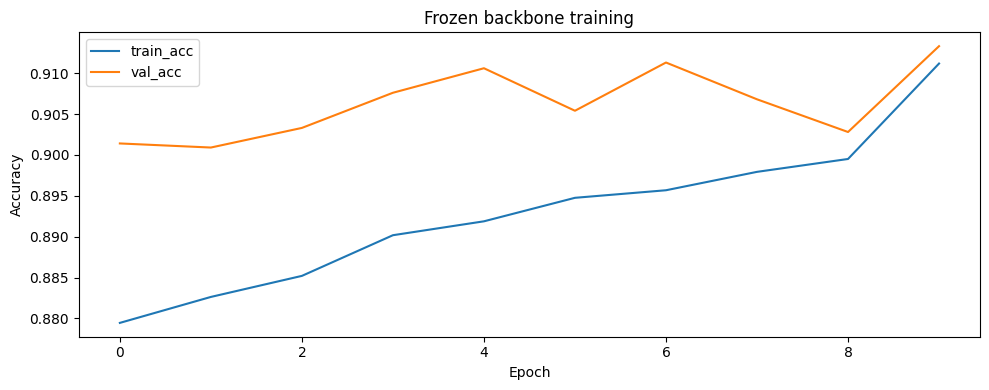

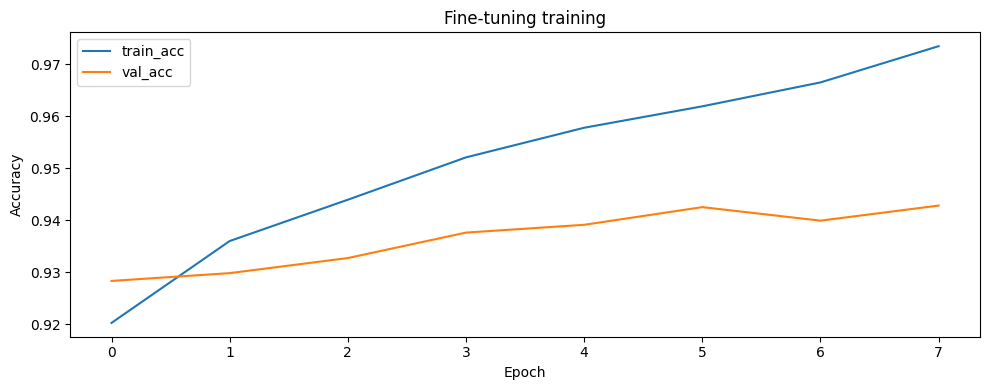

In [8]:
# 5) (Optional) Plot training curves
# -----------------------
def plot_history(hist, title):
    plt.figure(figsize=(10, 4))
    plt.plot(hist.history.get("accuracy", []), label="train_acc")
    plt.plot(hist.history.get("val_accuracy", []), label="val_acc")
    plt.title(title)
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_history(history, "Frozen backbone training")
plot_history(history_ft, "Fine-tuning training")